# Exploratory Data Analysis

This notebook contains the project section requested for the final ML presentation.


# Heavy Vehicle Failure Prediction Through Intelligent Sensor Data

## Complete Machine Learning Project Notebook

**Task:** Binary classification of APS-related failure in Scania heavy vehicles  
**Target:** `class` (`neg` = no APS-related failure, `pos` = APS-related failure)

This notebook contains the implementation, preprocessing, EDA, model training, tuning, evaluation, comparison, and final prediction demonstration required for the project review. Execute all cells from top to bottom before submission so the outputs and figures are visible.

The data contains 76,000 records, 170 sensor features, and a highly imbalanced target. Because missing a real failure can be costly, recall and F1-score are considered together with accuracy and ROC-AUC.


## 1. Import Libraries

The pipeline objects used later ensure that imputation and scaling are learned only from the training portion of the data. This prevents test-data leakage.


In [10]:
# If using Google Colab and a package is missing, run this once:
# !pip install -q scikit-learn matplotlib seaborn joblib

import os
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## 2. Load the Dataset

The original combined CSV is used because it contains both sensor values and the target label. The value `na` is converted to a real missing value while loading.


In [11]:
candidate_paths = [
    Path("D:\\ML\\HEAVY VEHICLE FAILURE PREDICTION THROUGH INTELLIGENT SENSOR\\dataset\\APS_Scania_Complete_Dataset.csv"),
    Path("APS_Scania_Complete_Dataset.csv"),
    Path("/content/APS_Scania_Complete_Dataset.csv"),
    Path("/content/HEAVY VEHICLE FAILURE PREDICTION THROUGH INTELLIGENT SENSOR/dataset/APS_Scania_Complete_Dataset.csv")
]
DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Place APS_Scania_Complete_Dataset.csv in the notebook folder or update DATA_PATH.")

df = pd.read_csv(DATA_PATH, na_values=["na"])
print("Dataset path:", DATA_PATH)
print("Dataset shape:", df.shape)
display(df.head())


Dataset path: D:\ML\HEAVY VEHICLE FAILURE PREDICTION THROUGH INTELLIGENT SENSOR\dataset\APS_Scania_Complete_Dataset.csv
Dataset shape: (76000, 171)


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,ag_005,ag_006,ag_007,ag_008,ag_009,ah_000,ai_000,aj_000,ak_000,al_000,am_0,an_000,ao_000,ap_000,aq_000,ar_000,as_000,at_000,au_000,av_000,ax_000,ay_000,ay_001,ay_002,ay_003,ay_004,ay_005,ay_006,ay_007,ay_008,ay_009,az_000,az_001,az_002,az_003,az_004,az_005,az_006,az_007,az_008,az_009,ba_000,ba_001,ba_002,ba_003,ba_004,ba_005,ba_006,ba_007,ba_008,ba_009,bb_000,bc_000,bd_000,be_000,bf_000,bg_000,bh_000,bi_000,bj_000,bk_000,bl_000,bm_000,bn_000,bo_000,bp_000,bq_000,br_000,bs_000,bt_000,bu_000,bv_000,bx_000,by_000,bz_000,ca_000,cb_000,cc_000,cd_000,ce_000,cf_000,cg_000,ch_000,ci_000,cj_000,ck_000,cl_000,cm_000,cn_000,cn_001,cn_002,cn_003,cn_004,cn_005,cn_006,cn_007,cn_008,cn_009,co_000,cp_000,cq_000,cr_000,cs_000,cs_001,cs_002,cs_003,cs_004,cs_005,cs_006,cs_007,cs_008,cs_009,ct_000,cu_000,cv_000,cx_000,cy_000,cz_000,da_000,db_000,dc_000,dd_000,de_000,df_000,dg_000,dh_000,di_000,dj_000,dk_000,dl_000,dm_000,dn_000,do_000,dp_000,dq_000,dr_000,ds_000,dt_000,du_000,dv_000,dx_000,dy_000,dz_000,ea_000,eb_000,ec_00,ed_000,ee_000,ee_001,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,0.0,37250.0,1432864.0,3664156.0,1007684.0,25896.0,0.0,2551696.0,0.0,0.0,0.0,0.0,0.0,4933296.0,3655166.0,1766008.0,1132040.0,0.0,0.0,0.0,0.0,1012.0,268.0,0.0,0.0,0.0,0.0,0.0,469014.0,4239660.0,703300.0,755876.0,0.0,5374.0,2108.0,4114.0,12348.0,615248.0,5526276.0,2378.0,4.0,0.0,0.0,2328746.0,1022304.0,415432.0,287230.0,310246.0,681504.0,1118814.0,3574.0,0.0,0.0,6700214.0,0.0,10.0,108.0,50.0,2551696.0,97518.0,947550.0,799478.0,330760.0,353400.0,299160.0,305200.0,283680.0,NaN,NaN,NaN,178540.0,76698.08,6700214.0,6700214.0,6599892.0,43566.0,68656.0,54064.0,638360.0,6167850.0,1209600.0,246244.0,2.0,96.0,0.0,5245752.00,0.0,916567.68,6.0,1924.0,0.0,0.0,0.0,118196.0,1309472.0,3247182.0,1381362.0,98822.0,11208.0,1608.0,220.0,240.0,6700214.0,NaN,10476.0,1226.0,267998.0,521832.0,428776.0,4015854.0,895240.0,26330.0,118.0,0.0,532.0,734.0,4122704.0,51288.0,0.0,532572.0,0.0,18.0,5330690.0,4732.0,1126.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,62282.0,85908.0,32790.0,0.0,0.0,202710.0,37928.0,14745580.0,1876644.0,0.0,0.0,0.0,0.0,2801180.0,2445.80,2712.0,965866.0,1706908.0,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,18254.0,653294.0,1720800.0,516724.0,31642.0,0.0,1393352.0,0.0,68.0,0.0,0.0,0.0,2560898.0,2127150.0,1084598.0,338544.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,71510.0,772720.0,1996924.0,99560.0,0.0,7336.0,7808.0,13776.0,13086.0,1010074.0,1873902.0,14726.0,6.0,0.0,0.0,1378576.0,447166.0,199512.0,154298.0,137280.0,138668.0,165908.0,229652.0,87082.0,4708.0,3646660.0,86.0,454.0,364.0,350.0,1393352.0,49028.0,688314.0,392208.0,341420.0,359780.0,366560.0,NaN,NaN,NaN,NaN,NaN,6700.0,33057.51,3646660.0,3646660.0,3582034.0,17733.0,260120.0,115626.0,6900.0,2942850.0,1209600.0,0.0,NaN,NaN,NaN,2291079.36,0.0,643536.96,0.0,0.0,0.0,0.0,38.0,98644.0,1179502.0,1286736.0,336388.0,36294.0,5192.0,56.0,NaN,0.0,3646660.0,NaN,6160.0,796.0,164860.0,350066.0,272956.0,1837600.0,301242.0,9148.0,22.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3312.0,522.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33736.0,36946.0,5936.0,0.0,0.0,103330.0,16254.0,4510080.0,868538.0,0.0,0.0,0.0,0.0,3477820.0,2211.76,2334.0,664504.0,824154.0,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,0.0,1648.0,370592.0,1883374.0,292936.0,12016.0,0.0,1234132.0,0.0,0.0,0.0,0.0,0.0,2371990.0,2173634.0,300796.0,153698.0,0.0,0.0,0.0,0.0,358.0,110.0,0.0,0.0,0.0,0.0,0.0,0.0,870456.0,239798.0,1450312.0,0.0,1620.0,1156.0,1228.0,34250.0,1811606.0,710672.0,34.0,0.0,0.0,0.0,790690.0,672026.0,332340.0,254892.0,189596.0,135758.0,103552.0,81666.0,46.0,0.0,2673338.0,128.0,202.0,576.0,4.0,1234132.0,28804.0,160176.0,139730.0,137160.0,13064

## 4. Data Preprocessing

Duplicate rows are checked and removed before splitting. The target is encoded as 0 and 1. Missing values are not filled manually here; the model pipelines below learn training-only median values during fitting.


In [12]:
print("Duplicate rows before removal:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

missing_summary = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (df.isna().mean() * 100).round(2)
}).sort_values("Missing_Percentage", ascending=False)

print("Duplicate rows after removal:", df.duplicated().sum())
print("Columns with missing values:", int((df.isna().sum() > 0).sum()))
print("Total missing cells:", int(df.isna().sum().sum()))
display(missing_summary.head(20))


Duplicate rows before removal: 0
Duplicate rows after removal: 0
Columns with missing values: 169
Total missing cells: 1078695


,Missing_Count,Missing_Percentage
br_000,62393,82.10
bq_000,61703,81.19
bp_000,60461,79.55
bo_000,58709,77.25
ab_000,58692,77.23
cr_000,58692,77.23
bn_000,55722,73.32
bm_000,50095,65.91
bl_000,34503,45.40
bk_000,29128,38.33


In [13]:
df["class"] = df["class"].map({"neg": 0, "pos": 1})

X = df.drop(columns=["class"])
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Initial dataset shape:", (76000, 171))
print("Final dataset shape after duplicate removal:", df.shape)
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Training class distribution:")
display(y_train.value_counts().rename_axis("class").to_frame("count"))
print("Testing class distribution:")
display(y_test.value_counts().rename_axis("class").to_frame("count"))


Initial dataset shape: (76000, 171)
Final dataset shape after duplicate removal: (76000, 171)
Training shape: (60800, 170)
Testing shape: (15200, 170)
Training class distribution:


,count
class,
0,59700
1,1100


Testing class distribution:


,count
class,
0,14925
1,275


### Leakage Prevention

The test set is held out before model fitting. Every model below uses a pipeline. The median imputer and scaler are fitted on training data only and then applied to validation or test data. This prevents information from the test set entering the training process.


## 5. Exploratory Data Analysis

The following plots inspect missingness, distributions, descriptive statistics, and correlations. Sensor outliers are retained because an extreme reading may represent an abnormal operating condition rather than an invalid value.


In [14]:
display(X.describe().T)


,count,mean,std,min,25%,50%,75%,max
aa_000,76000.0,6.115976e+04,2.647366e+05,0.0,860.0,30813.0,48840.0,4.294967e+07
ab_000,17308.0,7.255604e-01,3.311913e+00,0.0,0.0,0.0,0.0,2.040000e+02
ac_000,71739.0,3.564398e+08,7.952530e+08,0.0,16.0,154.0,970.0,2.130707e+09
ad_000,57158.0,1.506300e+05,3.590593e+07,0.0,24.0,128.0,430.0,8.584298e+09
ae_000,72810.0,6.736959e+00,1.534465e+02,0.0,0.0,0.0,0.0,2.105000e+04
...,...,...,...,...,...,...,...,...
ee_007,75137.0,3.475611e+05,1.707593e+06,0.0,112.0,41260.0,168046.0,1.195801e+08
ee_008,75137.0,1.398968e+05,4.692327e+05,0.0,0.0,3862.0,139500.0,1.926740e+07
ee_009,75137.0,8.424984e+03,4.875440e+04,0.0,0.0,0.0,2000.0,4.570398e+06
ef_000,72514.0,8.519734e-02,4.179600e+00,0.0,0.0,0.0,0.0,4.820000e+02


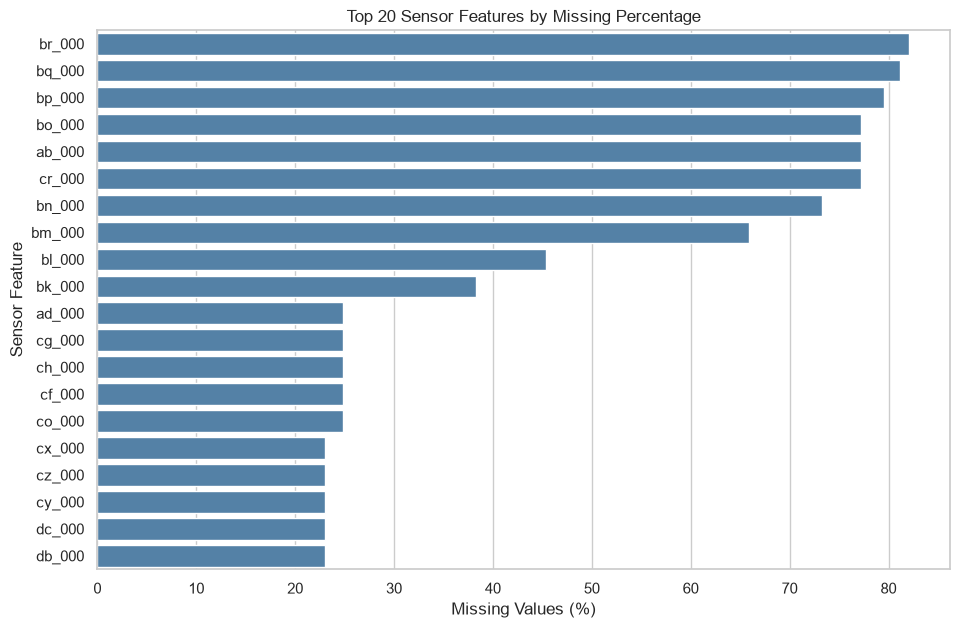

In [15]:
top_missing = missing_summary.drop(index="class", errors="ignore").head(20)
plt.figure(figsize=(11, 7))
sns.barplot(x=top_missing["Missing_Percentage"], y=top_missing.index, color="steelblue")
plt.title("Top 20 Sensor Features by Missing Percentage")
plt.xlabel("Missing Values (%)")
plt.ylabel("Sensor Feature")
plt.show()


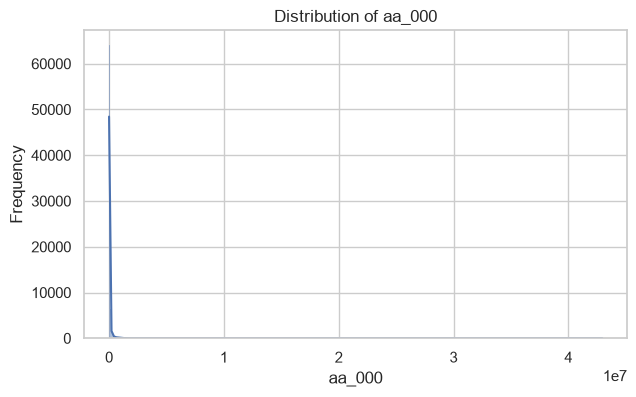

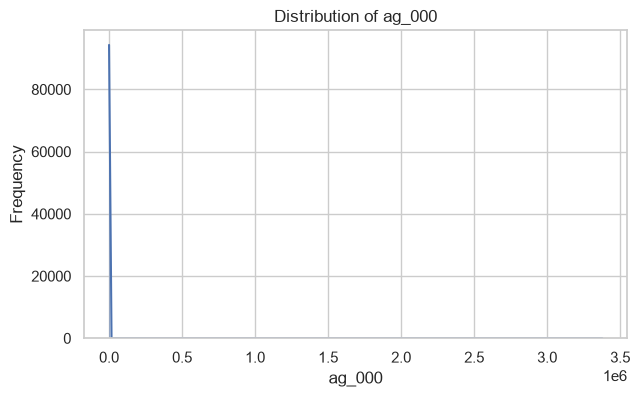

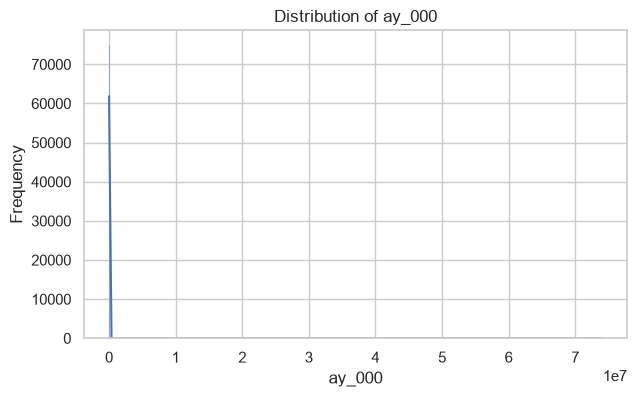

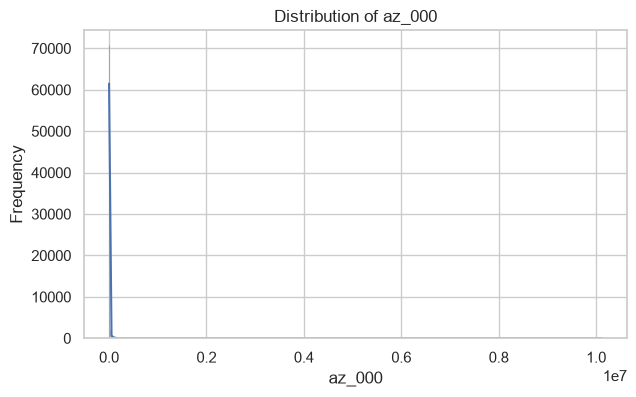

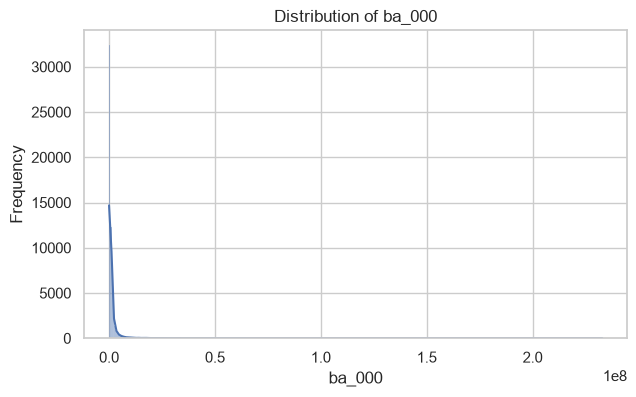

In [16]:
candidate_features = [c for c in ["aa_000", "ag_000", "ay_000", "az_000", "ba_000"] if c in X.columns]
for col in candidate_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(X[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


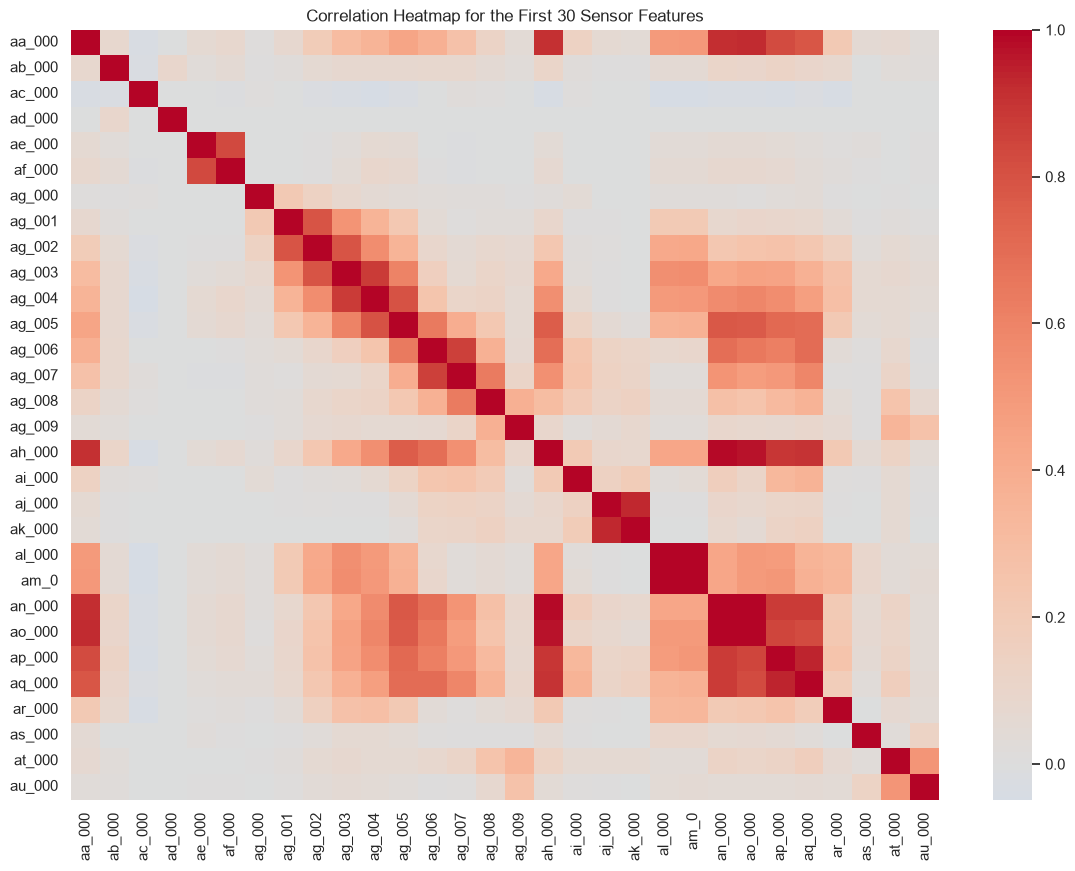

In [17]:
corr = X.corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(corr.iloc[:30, :30], cmap="coolwarm", center=0)
plt.title("Correlation Heatmap for the First 30 Sensor Features")
plt.show()


### EDA Observations

1. The target distribution is highly imbalanced, with far fewer positive failure cases.
2. Several sensor features contain substantial missingness, so median imputation is required.
3. Sensor variables have different scales and ranges; scaling is useful for Logistic Regression.
4. Correlated sensor readings may measure related vehicle behavior, but they are retained because their predictive value is not known before modelling.
